# Mahalanobis, LOF a spol.
## Jak hledat odlehlá pozorování ve vícerozměrných datech

**Blanka Šedivá, Katedra matematiky FAV ZČU Plzeň**

**Statistické dny — Česká statistická společnost 2026, Olomouc 10. - 11. září 2026**



---

> Odlehlá pozorování mohou představovat chyby měření, nestandardní procesy i zajímavé a potenciálně významné jevy. Jejich identifikace je proto důležitou součástí analýzy dat. 

> Zatímco v jednorozměrných datech bývá odhalení odlehlých hodnot relativně přímočaré, ve vícerozměrném prostoru se situace výrazně komplikuje. 

> Pozorování může být nenápadné při pohledu na jednotlivé proměnné, ale po zohlednění jejich vzájemných vztahů se ukáže jako výrazně odlehlé. S rostoucí dimensionalitou navíc selhávají intuitivní představy i některé tradiční postupy.


>  **Cílem** příspěvku není hledat univerzálně nejlepší metodu, ale ukázat výhody a omezení jednotlivých vybraných přístupů a ukázat, že volba vhodné metody závisí nejen na charakteru dat, ale také na cíli následné analýzy.

<!-- ## Harmonogram (orientační, ~45–50 min)

| # | Sekce | Doporučený čas | Poznámka |
|---|---|---|---|
| 1 | Motivace | 2–3 min | |
| 2 | Mahalanobisova vzdálenost + masking/MCD | 6–7 min | jádro přednášky |
| 3 | Kdy Mahalanobis selhává | 2–3 min | |
| 4 | LOF — princip a ukázka | 5 min | |
| 4.1 | Citlivost LOF na *k* | 3 min | |
| 5 | Další přístupy (přehledová mřížka) | 5–6 min | komentovat řádky, ne každý panel |
| 5.3 | Výpočetní náročnost metod | 2–3 min | jen graf + jedna věta shrnutí |
| 6 | Prokletí dimenzionality | 2–3 min | |
| 7.1 | Reálná data bez ground truth: `wine` | 4 min | konsensus metod bez znalosti pravdy |
| 7.2 | Reálná data s ground truth: mamografie | 5–6 min | kvantitativní srovnání (ROC-AUC) |
| 8 | Shrnutí a závěry | 2–3 min | |

Součet jádra: **~42–47 min** + prostor na dotazy. Pokud by bylo potřeba přednášku zkrátit zpět na 30 min,
nejsnazší je vypustit 4.1, 5.3 a jeden z panelů v sekci 5. -->


## Obsah

1. Motivace — proč nestačí dívat se na proměnné zvlášť
2. Mahalanobisova vzdálenost — klasika a její meze (maskování, robustní MCD)
3. Kdy Mahalanobis selhává — nekonvexní a shlukovaná data
4. Local Outlier Factor (LOF) — lokální hustota, citlivost na *k*
5. Další přístupy — Isolation Forest, One-Class SVM, k-NN vzdálenost
   - 5.3 výpočetní náročnost metod (škálování s *n*)
6. Prokletí dimenzionality
7. Reálná data — dva pohledy:
   - 7.1 bez ground truth (`wine`) — shoda a konsensus metod
   - 7.2 s ground truth (mamografie) — kvantitativní validace (ROC-AUC)
8. Shrnutí a doporučení


In [3]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')  # ztlumi varovani MCD/LOF na vetsich datech
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2  # potrebujeme chi2 kvantily pro mez Mahalanobisovy vzdalenosti

# --- metody odlehlosti a pomocne nastroje ze scikit-learn ---
from sklearn.covariance import EmpiricalCovariance, MinCovDet  # klasicky vs. robustni (MCD) odhad kovariance
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors  # LOF a k-NN vzdalenost
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler  # standardizace (nutna pro One-Class SVM, vhodna obecne)
from sklearn.decomposition import PCA  # pro 2D vizualizaci vicerozmernych dat
from sklearn.datasets import load_wine, make_moons  # ukazkove realne/syntetick datove sady

RNG = np.random.default_rng(2026)  # jeden sdileny generator nahodnych cisel -> reprodukovatelnost napric notebookem

# jednotny vzhled grafu pro celou prezentaci
plt.rcParams.update({
    'figure.figsize': (11, 4.2), 'figure.dpi': 110, 'font.size': 11,
    'axes.grid': True, 'grid.alpha': 0.3, 'axes.titlesize': 12,
    'legend.frameon': False, 'axes.spines.top': False, 'axes.spines.right': False,
})

C_IN, C_OUT = '#4C72B0', '#C44E52'  # jednotne barvy: modra = bezne, cervena = odlehle


def scatter(ax, X, flags=None, title='', s=20, legend=True):
    """Rozptylovy graf s vyznacenymi odlehlymi pozorovanimi.

    X:     pole (n, 2) - vykreslujeme jen prvni dve promenne/PCA slozky
    flags: booleovsky vektor delky n; True = pozorovani je oznaceno jako odlehle
    """
    if flags is None:
        ax.scatter(X[:, 0], X[:, 1], s=s, c=C_IN, alpha=.7, edgecolor='none')
    else:
        f = np.asarray(flags, dtype=bool)
        ax.scatter(X[~f, 0], X[~f, 1], s=s, c=C_IN, alpha=.55, edgecolor='none', label='bezne')
        ax.scatter(X[f, 0], X[f, 1], s=s * 2.5, c=C_OUT, marker='X',
                   label='odlehle (n={})'.format(int(f.sum())))
        if legend:
            ax.legend(loc='best', fontsize=9)
    ax.set_title(title)
    ax.set_xlabel('$X_1$')
    ax.set_ylabel('$X_2$')
    return ax


def flag_top(score, contamination=0.05):
    """Oznaci zadany podil pozorovani s nejvyssim skore odlehlosti.

    Sjednocuje ruzne metody na spolecny vystup (binarni vlajku), i kdyz kazda
    metoda vraci skore v jinem rozsahu (vzdalenost, LOF pomer, ...).
    Konvence pro vsechny skorovaci funkce v notebooku: vyssi skore = odlehlejsi.
    """
    k = max(1, int(round(contamination * len(score))))  # kolik bodu chceme oznacit
    thr = np.sort(score)[-k]                             # prah = k-ta nejvyssi hodnota skore
    return score >= thr


print('Prostredi pripraveno.')

Prostredi pripraveno.


---
# 1. Motivace

### Pozorování nemusí být odlehlé v žádné jednotlivé proměnné — a přesto je odlehlé

Silně korelovaná data: bod, který porušuje **vztah** mezi proměnnými, leží v marginálních rozděleních zcela nenápadně.

z-skóre podezřelého bodu:  X1 = -1.95   X2 = +2.10
percentil v X1: 2.3 %   |   percentil v X2: 98.3 %


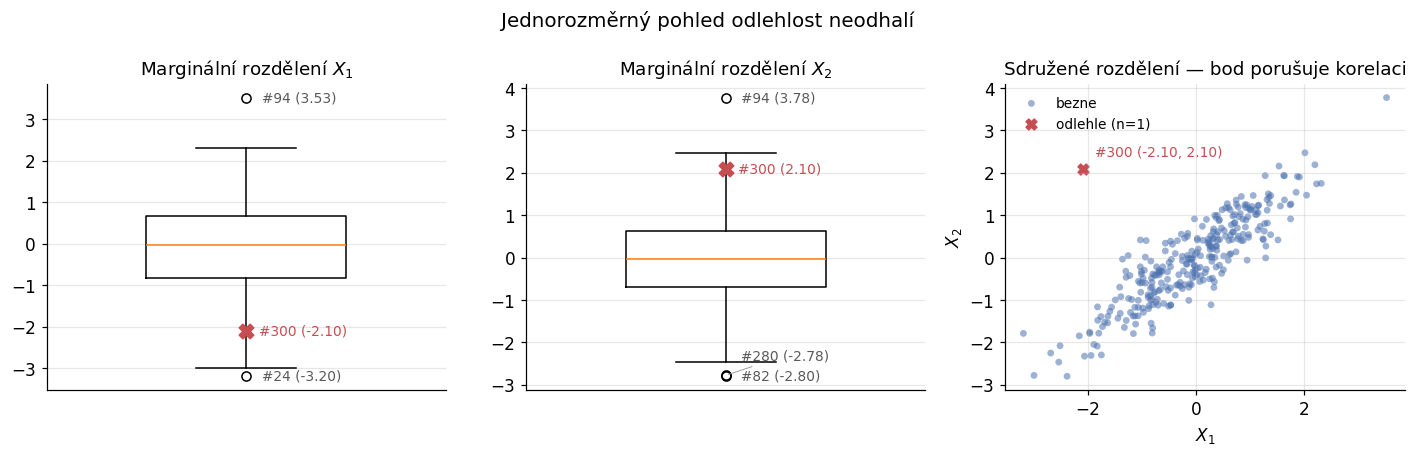

In [4]:
# Simulace: 300 bodu ze silne korelovaneho 2D normalniho rozdeleni (korelace 0.9)
n = 300
cov_true = np.array([[1.0, 0.9], [0.9, 1.0]])
X_mot = RNG.multivariate_normal([0, 0], cov_true, n)
suspect = np.array([-2.1, 2.1])          # bod "proti" korelaci - typicky pro X1, typicky pro X2, ale spolu nesedi
X_mot = np.vstack([X_mot, suspect])      # pridame podezrely bod na konec datove sady
i_susp = len(X_mot) - 1                  # jeho index

# z-skore a percentil ukazuji, ze bod NENI extremni v zadne jednotlive promenne
z = (X_mot - X_mot.mean(0)) / X_mot.std(0)
print('z-skóre podezřelého bodu:  X1 = {:+.2f}   X2 = {:+.2f}'.format(*z[i_susp]))
print('percentil v X1: {:.1f} %   |   percentil v X2: {:.1f} %'.format(
    100 * (X_mot[:, 0] < suspect[0]).mean(), 100 * (X_mot[:, 1] < suspect[1]).mean()))

# tri panely: boxplot X1, boxplot X2, a sdruzeny rozptylovy graf
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for j, ax in enumerate(axes[:2]):
    bp = ax.boxplot(X_mot[:, j], vert=True, widths=0.5)

    # popiskujeme VSECHNY body, ktere boxplot sam oznacil krouzkem (tzv. fliers) - bezne odlehle hodnoty
    flier_pairs = []
    for fy in bp['fliers'][0].get_ydata():
        f_idx = np.argmin(np.abs(X_mot[:, j] - fy))   # dohledame puvodni index bodu podle jeho hodnoty
        if f_idx != i_susp:                            # hlavni podezrely bod popisujeme zvlast nize
            flier_pairs.append((fy, f_idx))
    flier_pairs.sort()

    # pokud jsou dva krouzky bodu bity u sebe, jejich popisky by se prekryvaly -> rozestup + tenka spojnice
    data_span = X_mot[:, j].max() - X_mot[:, j].min()
    min_gap = data_span * 0.05
    stack, prev_y = 0, None
    for fy, f_idx in flier_pairs:
        stack = stack + 1 if (prev_y is not None and abs(fy - prev_y) < min_gap) else 0
        prev_y = fy
        dy = stack * 13   # pri kolizi posuneme dalsi popisek o kousek vys
        ax.annotate('#{} ({:.2f})'.format(f_idx, fy), xy=(1, fy),
                    xytext=(10, dy), textcoords='offset points', fontsize=9, color='0.35', va='center',
                    arrowprops=dict(arrowstyle='-', color='0.6', lw=0.6) if stack else None)

    ax.scatter([1], [suspect[j]], s=90, c=C_OUT, marker='X', zorder=5)  # kde lezi podezrely bod v marginale
    ax.annotate('#{} ({:.2f})'.format(i_susp, suspect[j]), xy=(1, suspect[j]),
                xytext=(8, 0), textcoords='offset points', fontsize=9, color=C_OUT, va='center')
    ax.set_title('Marginální rozdělení $X_{}$'.format(j + 1))
    ax.set_xticks([])

flags = np.zeros(len(X_mot), bool)
flags[i_susp] = True
scatter(axes[2], X_mot, flags, 'Sdružené rozdělení — bod porušuje korelaci')
axes[2].annotate('#{} ({:.2f}, {:.2f})'.format(i_susp, suspect[0], suspect[1]), xy=tuple(suspect),
                 xytext=(8, 8), textcoords='offset points', fontsize=9, color=C_OUT)
fig.suptitle('Jednorozměrný pohled odlehlost neodhalí', fontsize=13)
fig.tight_layout()
plt.show()

---
# 2. Mahalanobisova vzdálenost

$$ d_M^2(\mathbf{x}) = (\mathbf{x}-\boldsymbol\mu)^\top \boldsymbol\Sigma^{-1} (\mathbf{x}-\boldsymbol\mu) $$

- Euklidovská vzdálenost **standardizovaná kovarianční strukturou** — vrstevnice jsou elipsy.
- Pro vícerozměrné normální rozdělení platí $d_M^2 \sim \chi^2_p$ → přirozená mez $\chi^2_p(1-\alpha)$.
- Invariantní vůči lineárním transformacím (na měřítku nezáleží).

Mez chi2_2(0.950) = 5.99
d_M^2 podezřelého bodu = 60.6  ->  ODLEHLÉ


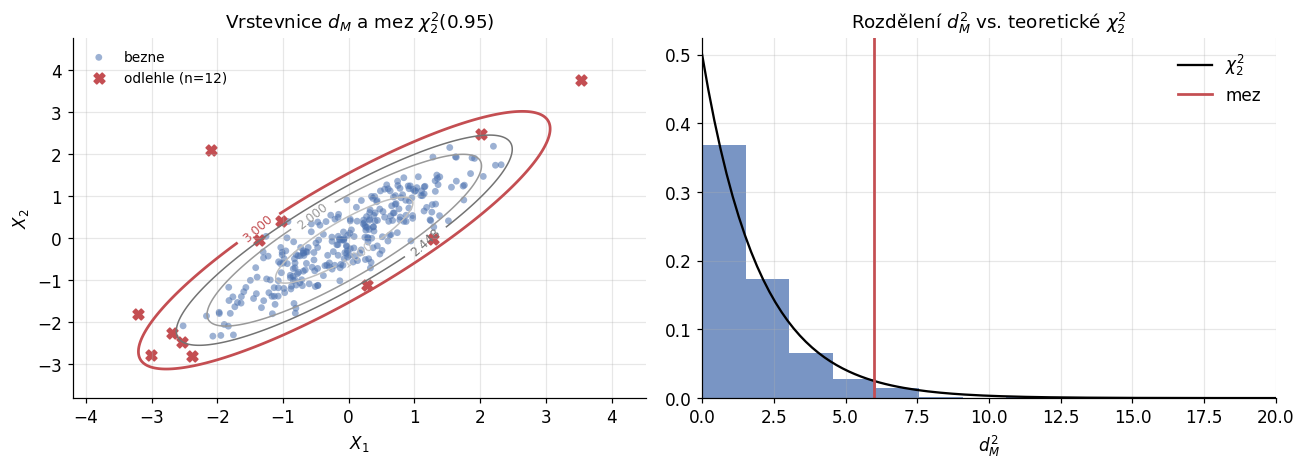

In [5]:
p = 2                    # pocet promennych (dimenze)
alpha = 0.05            # hladina vyznamnosti -> hranice na 95% kvantilu
thr = chi2.ppf(1 - alpha, df=p)   # kriticka hodnota d_M^2, nad kterou prohlasime bod za odlehly

emp = EmpiricalCovariance().fit(X_mot)      # klasicky (nerobustni) odhad prumeru a kovariancni matice
d2 = emp.mahalanobis(X_mot)                 # kvadrat Mahalanobisovy vzdalenosti pro kazde pozorovani
flags_m = d2 > thr                          # binarni oznaceni odlehlych

print('Mez chi2_{}({:.3f}) = {:.2f}'.format(p, 1 - alpha, thr))
print('d_M^2 podezřelého bodu = {:.1f}  ->  {}'.format(
    d2[i_susp], 'ODLEHLÉ' if flags_m[i_susp] else 'běžné'))

# mrizka bodu pro vykresleni vrstevnic (kontur) Mahalanobisovy vzdalenosti
gx, gy = np.meshgrid(np.linspace(*np.percentile(X_mot[:, 0], [0, 100]) + [-1, 1], 300),
                     np.linspace(*np.percentile(X_mot[:, 1], [0, 100]) + [-1, 1], 300))
grid = np.c_[gx.ravel(), gy.ravel()]
zz = emp.mahalanobis(grid).reshape(gx.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
# vrstevnice ve tvaru sqrt(d_M^2): elipsy soustredne kolem prumeru, posledni (cervena) = kriticka mez
levels_sorted = sorted(set([1, 2, 3, np.sqrt(thr)]))
level_colors = ['0.75', '0.6', '0.45', C_OUT][:len(levels_sorted)]
cs = axes[0].contour(gx, gy, np.sqrt(zz), levels=levels_sorted,
                     colors=level_colors, linewidths=[1] * (len(levels_sorted) - 1) + [1.8])
axes[0].clabel(cs, inline=True, fontsize=8)
scatter(axes[0], X_mot, flags_m, 'Vrstevnice $d_M$ a mez $\\chi^2_2(0.95)$')

# histogram skutecneho rozdeleni d_M^2 vs. teoreticke chi-kvadrat rozdeleni - melo by sedet pro normalni data
axes[1].hist(d2, bins=40, color=C_IN, alpha=.75, density=True)
xs = np.linspace(0, max(d2) * 1.05, 300)
axes[1].plot(xs, chi2.pdf(xs, df=p), color='k', lw=1.5, label='$\\chi^2_2$')
axes[1].set_xlim(0,20)
axes[1].axvline(thr, color=C_OUT, lw=1.8, label='mez')
axes[1].set_title('Rozdělení $d_M^2$ vs. teoretické $\\chi^2_2$')
axes[1].set_xlabel('$d_M^2$')
axes[1].legend()
fig.tight_layout()
plt.show()

## 2.1 Maskování (masking) a zahlcení (swamping)

Průměr i kovarianční matice se počítají **ze všech dat včetně odlehlých hodnot**.
Skupina odlehlých pozorování si „natáhne" elipsu k sobě a tím se sama zamaskuje.

**Řešení:** robustní odhad polohy a rozptylu — *Minimum Covariance Determinant* (MCD), Rousseeuw (1984).

**Princip:** z $n$ pozorování hledáme podmnožinu $h$ bodů ($h \le n$), pro kterou má výběrová
kovarianční matice **nejmenší determinant** — tedy nejkompaktnější, „nejtěsnější" elipsoid, jaký lze
z dat vybrat. Determinant kovarianční matice odpovídá (druhé mocnině) objemu elipsoidu, který data
opisuje, takže minimalizace determinantu = hledání nejhutnějšího jádra dat. Odlehlé body leží mimo
toto jádro, a proto se do odhadu $\mu$ a $\Sigma$ vůbec nepromítnou.

- **Volba $h$:** podíl $h/n$ udává parametr `support_fraction` (výchozí hodnota v scikit-learn odpovídá
  $h \approx (n+p+1)/2$, tj. cca polovina dat). Čím menší $h/n$, tím vyšší **breakdown point** (odolnost
  vůči podílu kontaminovaných dat), ale tím méně dat se pro odhad využije — kompromis mezi robustností
  a efektivitou.
- **Výpočet:** prohledat všechny $\binom{n}{h}$ podmnožiny je prakticky nemožné, proto se používá
  algoritmus **FastMCD** (Rousseeuw & Van Driessen, 1999) — iterativní *C-step*, který od náhodných
  počátečních podmnožin rychle konverguje k lokálnímu minimu determinantu.
- **Dopočet:** z vybraného $h$-jádra se spočítá robustní $\hat\mu, \hat\Sigma$ (případně škálované na
  konzistenci s normálním rozdělením) a teprve s nimi se počítá Mahalanobisova vzdálenost pro *všechna*
  pozorování — včetně těch mimo jádro.
- Na rozdíl od klasického odhadu (breakdown point 0 % — jediný extrémní bod může libovolně zkreslit
  $\mu$ i $\Sigma$) MCD toleruje kontaminaci až do zhruba 50 % dat, podle zvoleného $h$.

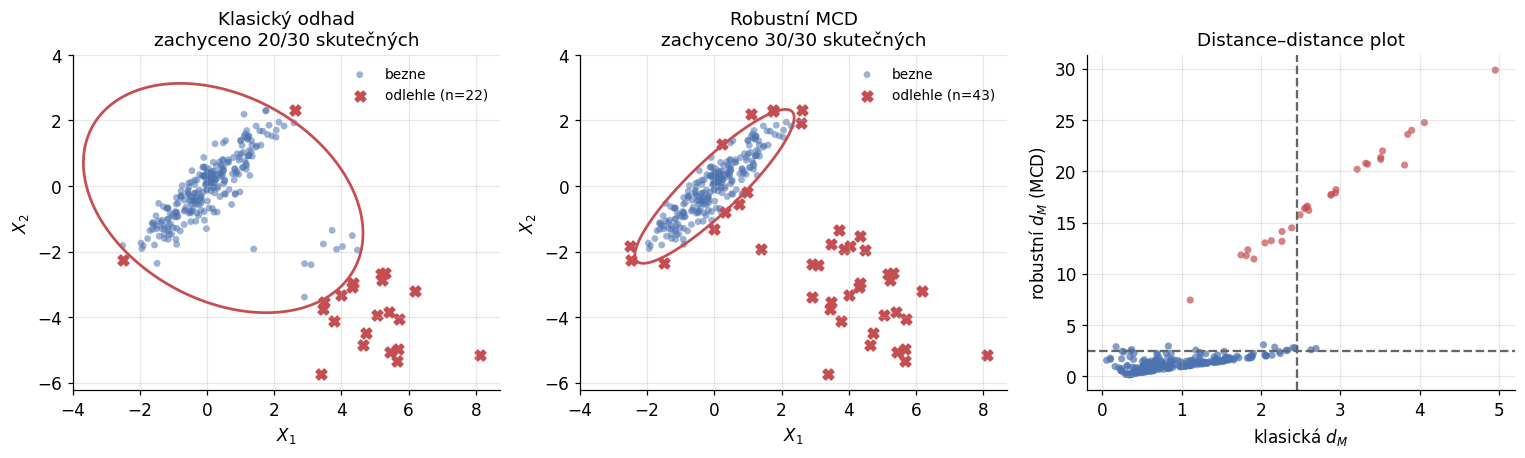

In [6]:
# hlavni shluk (250 beznych bodu) + kompaktni skupina 30 skutecne odlehlych bodu opodal
X_clean = RNG.multivariate_normal([0, 0], cov_true, 250)
X_group = RNG.multivariate_normal([4.5, -3.0], np.array([[2.0, -0.9], [-0.9, 2.0]]), 30)   # kompaktni skupina odlehlych
X_mask = np.vstack([X_clean, X_group])
true_out = np.r_[np.zeros(len(X_clean), bool), np.ones(len(X_group), bool)]  # zde zname "pravdu" (jde o simulaci)

fit_emp = EmpiricalCovariance().fit(X_mask)                       # klasicky odhad - pocita se ze VSECH dat (sklearn.covariance)
fit_mcd = MinCovDet(random_state=0).fit(X_mask)                   # MCD - hleda nejkompaktnejsi podmnozinu dat (sklearn.covariance)

# mrizka pro dokresleni hranicni elipsy (d_M = mez) obou odhadu
gx2, gy2 = np.meshgrid(np.linspace(-4, 7, 250), np.linspace(-5, 4, 250))
grid2 = np.c_[gx2.ravel(), gy2.ravel()]

res = {}
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
for ax, (name, fit) in zip(axes[:2], [('Klasický odhad', fit_emp), ('Robustní MCD', fit_mcd)]):
    d2_ = fit.mahalanobis(X_mask)
    f_ = d2_ > thr
    res[name] = d2_
    zz = fit.mahalanobis(grid2).reshape(gx2.shape)
    ax.contour(gx2, gy2, zz, levels=[thr], colors=[C_OUT], linewidths=1.8)
    scatter(ax, X_mask, f_, '{}\nzachyceno {}/{} skutečných'.format(
        name, int((f_ & true_out).sum()), int(true_out.sum())))

# distance-distance plot: srovnani klasicke a robustni vzdalenosti bod po bodu
axes[2].scatter(np.sqrt(res['Klasický odhad']), np.sqrt(res['Robustní MCD']),
                s=22, c=np.where(true_out, C_OUT, C_IN), alpha=.7, edgecolor='none')
axes[2].axhline(np.sqrt(thr), color='0.4', ls='--')
axes[2].axvline(np.sqrt(thr), color='0.4', ls='--')
axes[2].set_xlabel('klasická $d_M$')
axes[2].set_ylabel('robustní $d_M$ (MCD)')
axes[2].set_title('Distance–distance plot')
fig.tight_layout()
plt.show()

---
# 3. Kdy Mahalanobis selhává

Mahalanobisova vzdálenost implicitně předpokládá **jedno unimodální, přibližně eliptické rozdělení**.
Pokud data tvoří více shluků nebo nelineární strukturu, je „střed dat“ často místo, kde žádná data nejsou.

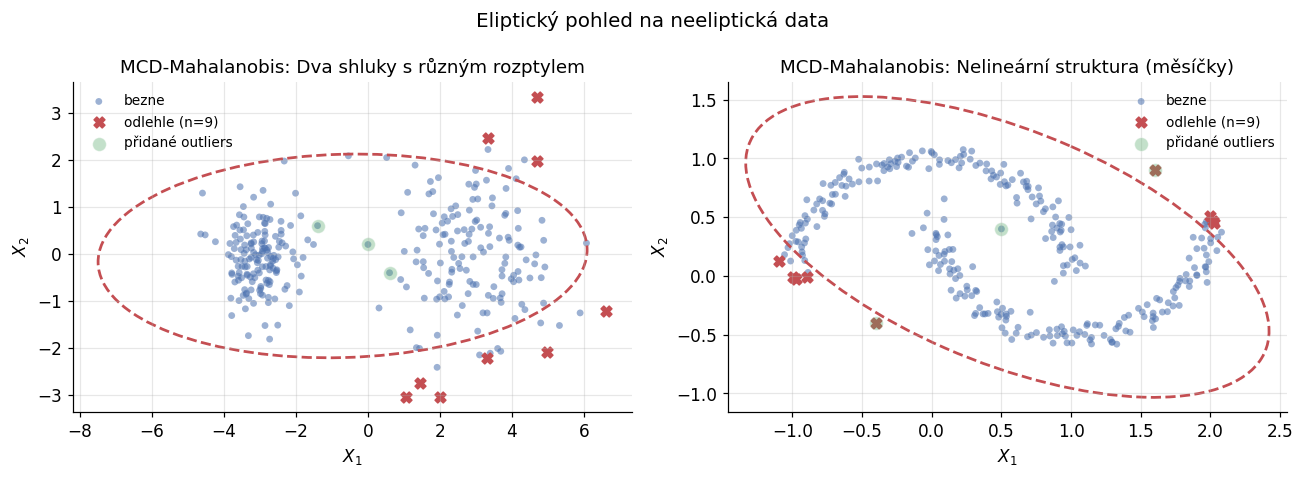

In [7]:
def ds_two_clusters(rng):
    """Dva gaussovske shluky s ruznym rozptylem + par bodu presne mezi nimi."""
    a = rng.multivariate_normal([-3, 0], 0.35 * np.eye(2), 150)
    b = rng.multivariate_normal([3, 0], 1.4 * np.eye(2), 150)
    o = np.array([[0.0, 0.2], [-1.4, 0.6], [0.6, -0.4]])   # body "mezi" shluky
    return np.vstack([a, b, o])


def ds_moons(rng):
    """Klasicka nelinearni "mesickova" struktura + tri body v mezerach mezi mesici."""
    X, _ = make_moons(n_samples=300, noise=0.06, random_state=1)            # generator dat zklearn.datasets
    o = np.array([[0.5, 0.4], [-0.4, -0.4], [1.6, 0.9]])
    return np.vstack([X, o])


if 'RNG' not in globals():
    RNG = np.random.default_rng(2026)

from matplotlib.patches import Ellipse


def draw_cov_ellipse(ax, fit, chi2_val, **kwargs):
    """Nakresli elipsu d_M^2 = chi2_val kolem (robustniho) prumeru fit.location_/fit.covariance_.

    Poloosy elipsy jsou dany vlastnimi cisly kovariani matice (skalovanymi na chi2_val),
    natoceni elipsy pak jejimi vlastnimi vektory.
    """
    vals, vecs = np.linalg.eigh(fit.covariance_)
    order = np.argsort(vals)[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * np.sqrt(vals * chi2_val)   # plne osy (ne polo-osy) elipsy
    ax.add_patch(Ellipse(fit.location_, width, height, angle=angle, **kwargs))


X_2c, X_mn = ds_two_clusters(RNG), ds_moons(RNG)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, Xd, name in [(axes[0], X_2c, 'Dva shluky s různým rozptylem'),
                     (axes[1], X_mn, 'Nelineární struktura (měsíčky)')]:
    fit = MinCovDet(random_state=0).fit(Xd)      # robustni odhad prumeru a kovariance (jadro MCD)
    # MCD-Mahalanobis: 3 % bodu s nejvyssi vzdalenosti od (robustniho) prumeru
    f = flag_top(fit.mahalanobis(Xd), 0.03)
    scatter(ax, Xd, f, 'MCD-Mahalanobis: {}'.format(name))
    ax.scatter(Xd[-3:, 0], Xd[-3:, 1], s=80, c='#55A868', marker='o', alpha=0.35,
               edgecolor='white', linewidth=.7, label='přidané outliers')
    ax.legend(loc='best', fontsize=9)
    # elipsa d_M^2 = mez chi2_2(0.95) - vizualizuje implicitni eliptickou predstavu MCD o datech
    draw_cov_ellipse(ax, fit, thr, fill=False, edgecolor=C_OUT, lw=1.8, ls='--')
fig.suptitle('Eliptický pohled na neeliptická data', fontsize=13)
fig.tight_layout()
plt.show()

Body ležící **mezi shluky** (evidentně netypické) mají malou Mahalanobisovu vzdálenost — jsou blízko globálního průměru.
Naopak zcela regulérní okrajová pozorování hustého shluku jsou označena jako odlehlá.

→ Potřebujeme kritérium založené na **lokální** struktuře dat.

---
# 4. Local Outlier Factor (LOF)

Breunig et al. (2000). Myšlenka: porovnej **lokální hustotu bodu** s lokální hustotou jeho $k$ nejbližších sousedů.

1. $k\text{-distance}(A)$ — vzdálenost k $k$-tému nejbližšímu sousedovi
2. $N_k(A)$ — množina $k$ nejbližších sousedů bodu $A$, tj. všech bodů $B \neq A$ splňujících $d(A,B) \le k\text{-distance}(A)$
3. *reachability distance*: $\;\text{rd}_k(A,B) = \max\{k\text{-dist}(B),\ d(A,B)\}$, kde $d(A,B)$ je vzdálenost mezi body $A$ a $B$
4. *local reachability density*: $\;\text{lrd}_k(A) = \left(\dfrac{1}{|N_k(A)|}\sum_{B \in N_k(A)} \text{rd}_k(A,B)\right)^{-1}$
5. $$\text{LOF}_k(A) = \frac{1}{k}\sum_{B \in N_k(A)} \frac{\text{lrd}_k(B)}{\text{lrd}_k(A)}$$

**Interpretace:** $\text{LOF}\approx 1$ → stejná hustota jako okolí; $\text{LOF}\gg 1$ → bod je řidší než jeho sousedé → lokálně odlehlý.

> **Poznámka k metrice:** $d(A,B)$ může být libovolná vzdálenostní metrika (euklidovská, Manhattan, kosinová…) — definice LOF na konkrétní volbě nezávisí. V tomto notebooku používáme výchozí nastavení `LocalOutlierFactor` ze scikit-learn, tedy euklidovskou vzdálenost (`metric='minkowski'`, `p=2`).

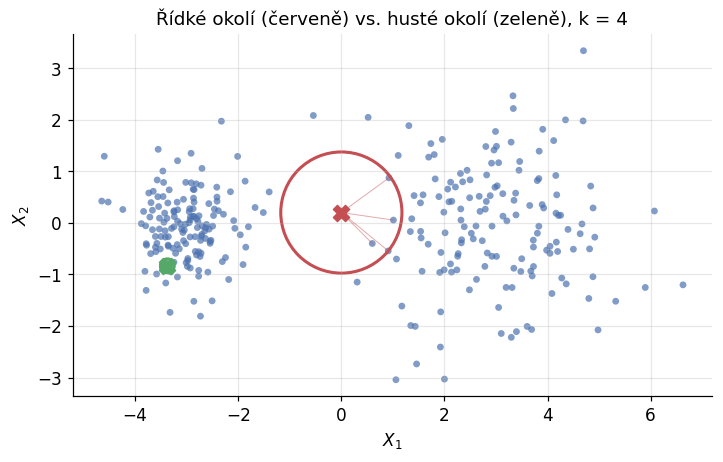

In [8]:
k_demo = 4

nn = NearestNeighbors(n_neighbors=k_demo + 1).fit(X_2c)  # +1, protoze bod je vlastnim nejblizsim sousedem (vzdalenost 0)
dist, idx = nn.kneighbors(X_2c)   # dist[i, -1] = k-distance bodu i; idx[i, 1:] = jeho k nejblizsim sousedu

fig, ax = plt.subplots(figsize=(7.5, 5.5))
scatter(ax, X_2c, legend=False)
# vybirame dva ilustracni body: jeden z ridke oblasti (cervene), jeden z huste (zelene)
for pt, color in [(len(X_2c) - 3, C_OUT), (5, '#55A868')]:
    r = dist[pt, -1]  # polomer kruhu = k-distance daneho bodu
    ax.add_patch(plt.Circle(X_2c[pt], r, fill=False, color=color, lw=2))
    ax.scatter(*X_2c[pt], s=110, c=color, marker='X', zorder=5)
    for j in idx[pt, 1:]:
        ax.plot(*zip(X_2c[pt], X_2c[j]), color=color, lw=.6, alpha=.5)  # spojnice k sousedum
ax.set_aspect('equal')
ax.set_title('Řídké okolí (červeně) vs. husté okolí (zeleně), k = {}'.format(k_demo))
plt.show()

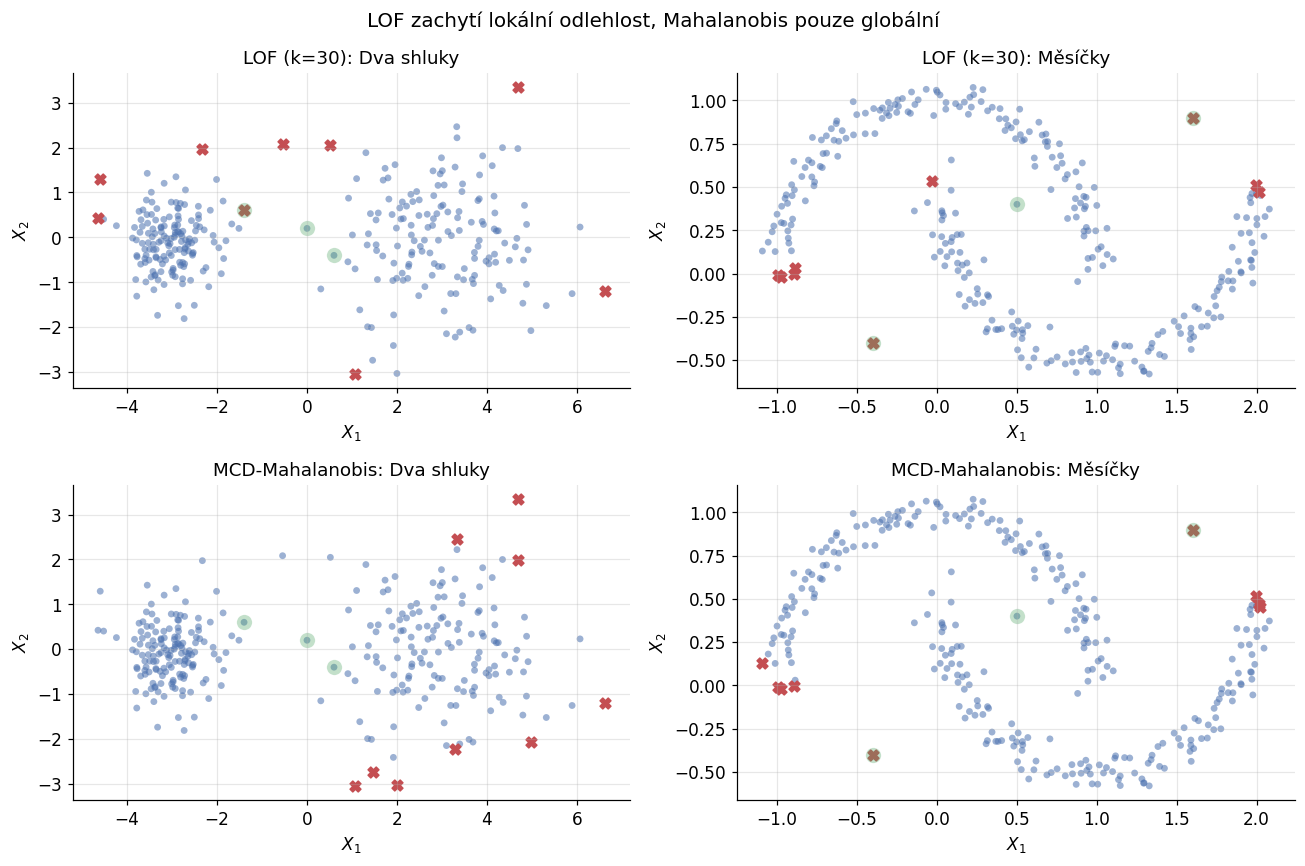

In [9]:
k_demo = 30
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for col, (Xd, name) in enumerate([(X_2c, 'Dva shluky'), (X_mn, 'Měsíčky')]):
    lof = LocalOutlierFactor(n_neighbors=k_demo)
    lof.fit(Xd)
    score = -lof.negative_outlier_factor_          # sklearn vraci zaporne skore, otocime -> >1 znamena odlehle
    scatter(axes[0, col], Xd, flag_top(score, 0.03), 'LOF (k={}): {}'.format(k_demo, name))
    scatter(axes[1, col], Xd,
            flag_top(MinCovDet(random_state=0).fit(Xd).mahalanobis(Xd), 0.03),
            'MCD-Mahalanobis: {}'.format(name))
    for row in range(2):
        axes[row, col].scatter(Xd[-3:, 0], Xd[-3:, 1], s=100, c='#55A868', marker='o',
                               edgecolor='white', linewidth=.2, alpha=0.35)
        legend = axes[row, col].get_legend()
        if legend is not None:
            legend.remove()
fig.suptitle('LOF zachytí lokální odlehlost, Mahalanobis pouze globální', fontsize=13)
fig.tight_layout()
plt.show()

## 4.1 Citlivost LOF na volbu $k$


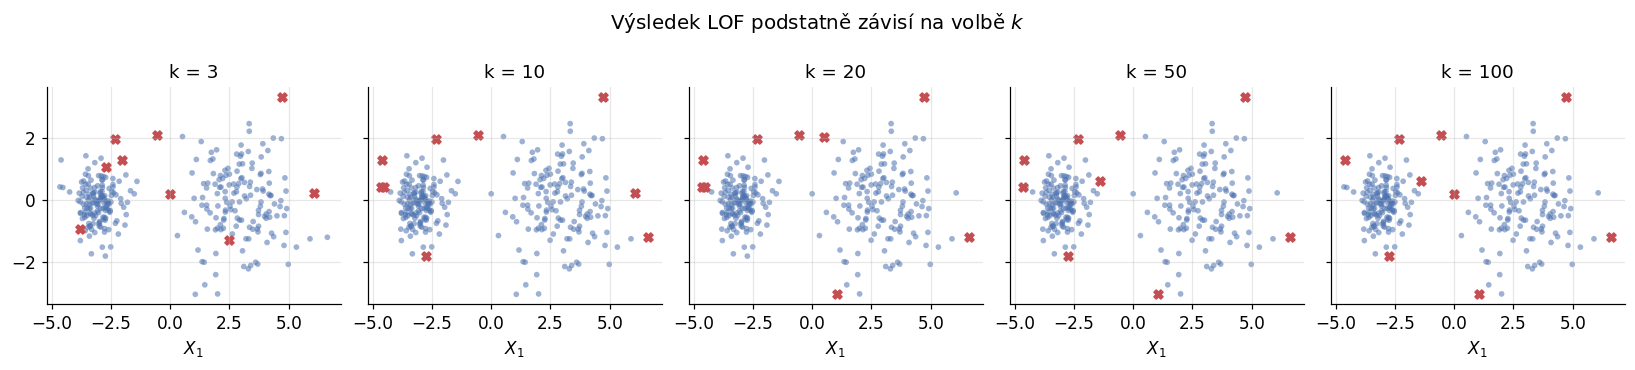

In [10]:
ks = [3, 10, 20, 50, 100]   # postupne zvetsujeme velikost "lokalniho" okoli
fig, axes = plt.subplots(1, len(ks), figsize=(15, 3.4), sharex=True, sharey=True)
for ax, k in zip(axes, ks):
    s = -LocalOutlierFactor(n_neighbors=k).fit(X_2c).negative_outlier_factor_
    scatter(ax, X_2c, flag_top(s, 0.03), 'k = {}'.format(k), s=14, legend=False)
    ax.set_ylabel('')
fig.suptitle('Výsledek LOF podstatně závisí na volbě $k$', fontsize=13)
fig.tight_layout()
plt.show()

---
# 5. Další často používané přístupy

| Metoda | Princip | Předpoklad / laditelný parametr |
|---|---|---|
| Mahalanobis (klasický) | vzdálenost od průměru vážená $\Sigma^{-1}$ | eliptické rozdělení; není robustní |
| Mahalanobis (MCD) | robustní odhad $\mu,\Sigma$ | eliptické rozdělení; `support_fraction` |
| $k$-NN vzdálenost | vzdálenost ke $k$-tému sousedovi | globální hustota; $k$ |
| LOF | poměr lokálních hustot | lokální hustota; $k$ |
| Isolation Forest | snadnost izolace náhodnými řezy | bez předpokladu tvaru; počet stromů |
| One-Class SVM | obálka nosiče rozdělení | jádro, $\nu$, $\gamma$ |

## 5.1 Isolation Forest

Liu, Ting, Zhou (2008). Myšlenka: odlehlé body jsou „few and different" — dají se izolovat od zbytku dat velmi rychle náhodným dělením prostoru, protože leží v řídkých oblastech daleko od hustého jádra.

**Konstrukce stromu (iTree):** opakovaně náhodně vyber příznak a náhodnou dělicí hodnotu mezi jeho min a max v aktuálním uzlu, rozděl data na dvě větve; opakuj, dokud uzel neobsahuje jediný bod nebo není dosažena maximální hloubka. Les (`IsolationForest`) tvoří `n_estimators` takových stromů, každý postavený na náhodném podvzorku dat (`max_samples`).

**Skóre odlehlosti:** pro bod $x$ spočti průměrnou hloubku $h(x)$, ve které byl izolován napříč všemi stromy, a normalizuj ji vzhledem k očekávané hloubce:

$$s(x, n) = 2^{-E[h(x)]/c(n)}, \qquad c(n) = 2H(n-1) - \frac{2(n-1)}{n}$$

kde $c(n)$ je očekávaná hloubka neúspěšného vyhledávání v binárním vyhledávacím stromu o $n$ uzlech (normalizační konstanta) a $H(i)$ je $i$-té harmonické číslo.

**Interpretace:** $s \to 1$ → bod izolován velmi mělko → odlehlý; $s \approx 0.5$ → typická hloubka, běžný bod; $s \ll 0.5$ → bod hluboko v hustém jádru, jednoznačně normální.

- Žádný předpoklad o tvaru rozdělení dat, žádný výpočet vzdáleností ani hustot.
- Časová složitost $O(n\log n)$, prakticky nezávislá na počtu příznaků → dobře škáluje do vysokých dimenzí i velkých datových sad (viz sekce 5.3).
- Citlivé na náhodnost (různé `random_state` dají mírně odlišné skóre) a na osové (axis-parallel) řezy, které mohou zkreslit skóre u šikmo orientovaných struktur.

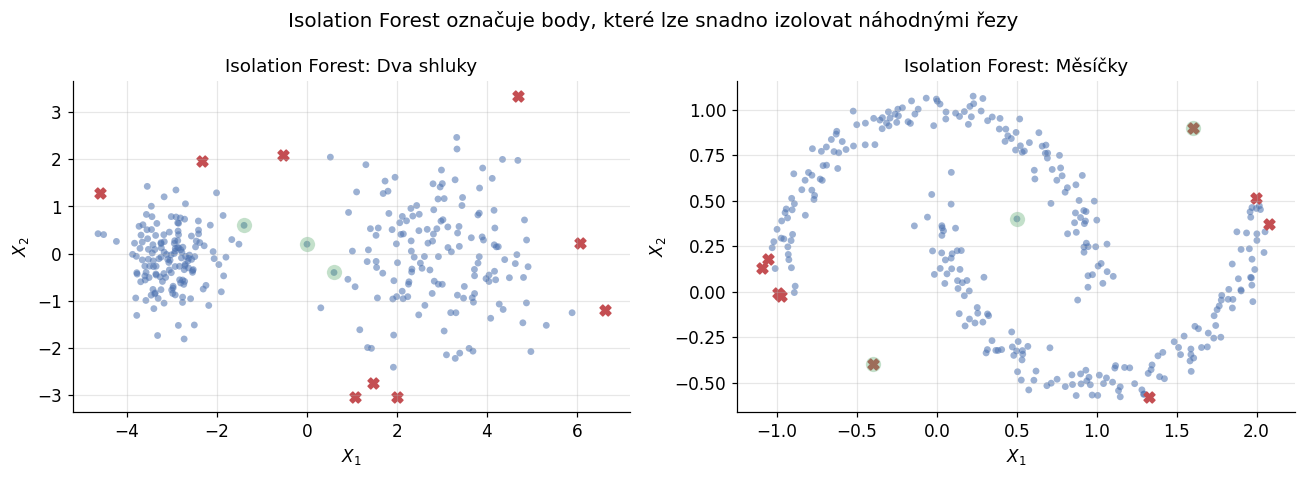

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, Xd, name in [(axes[0], X_2c, 'Dva shluky'),
                     (axes[1], X_mn, 'Měsíčky')]:
    iso = IsolationForest(n_estimators=300, random_state=0)
    score = -iso.fit(Xd).score_samples(Xd)  # vyšší skóre = snadněji izolovatelný bod
    flags_iso = flag_top(score, 0.03)
    scatter(ax, Xd, flags_iso, 'Isolation Forest: {}'.format(name), legend=False)
    ax.scatter(Xd[-3:, 0], Xd[-3:, 1], s=100, c='#55A868', marker='o',
               edgecolor='white', linewidth=.2, alpha=0.35)
fig.suptitle('Isolation Forest označuje body, které lze snadno izolovat náhodnými řezy', fontsize=13)
fig.tight_layout()
plt.show()

## 5.2 One-Class SVM

Schölkopf et al. (2001). Myšlenka: najdi v prostoru příznaků (případně po nelineárním zobrazení jádrem) nejmenší možnou oblast, která obsahuje většinu dat — vše mimo ni je odlehlé.

Formálně se hledá nadrovina oddělující data od počátku s maximální marží:

$$\min_{w,\xi,\rho} \ \tfrac12\|w\|^2 + \tfrac{1}{\nu n}\sum_i \xi_i - \rho \qquad \text{s.t. } (w\cdot\phi(x_i)) \ge \rho - \xi_i,\ \xi_i \ge 0$$

Rozhodovací funkce: $f(x) = \text{sign}\big((w\cdot\phi(x)) - \rho\big)$; $f(x) < 0$ → bod je odlehlý.

- **$\nu \in (0,1]$** je současně horní mez podílu odlehlých bodů (chyb) v trénovacích datech a dolní mez podílu podpůrných vektorů — přímo řídí, kolik dat metoda „obětuje" jako odlehlé.
- **jádro (kernel)** — v notebooku RBF; parametr **$\gamma$** určuje flexibilitu hranice: malé $\gamma$ → hladká, téměř eliptická hranice, velké $\gamma$ → lokální, členitá hranice s rizikem přeučení.
- Jde o kernel/vzdálenostní metodu → **vyžaduje standardizaci** vstupních dat (viz `StandardScaler` v kódu níže), jinak by proměnné s větším měřítkem dominovaly.

In [12]:
def s_maha(X):
    """Klasicka Mahalanobisova vzdalenost (nerobustni prumer a kovariance)."""
    return EmpiricalCovariance().fit(X).mahalanobis(X)


def s_mcd(X):
    """Robustni varianta - kovariance odhadnuta metodou Minimum Covariance Determinant."""
    return MinCovDet(random_state=0, support_fraction=0.75).fit(X).mahalanobis(X)


def s_knn(X, k=20):
    """Vzdalenost ke k-temu nejblizsimu sousedovi - jednoducha globalni miru hustoty."""
    d, _ = NearestNeighbors(n_neighbors=k + 1).fit(X).kneighbors(X)
    return d[:, -1]


def s_lof(X, k=20):
    """Local Outlier Factor - pomer lokalnich hustot bodu a jeho sousedu."""
    return -LocalOutlierFactor(n_neighbors=min(k, len(X) - 1)).fit(X).negative_outlier_factor_


def s_iforest(X):
    """Isolation Forest - cim snaze lze bod izolovat nahodnymi rezy, tim je odlehlejsi."""
    return -IsolationForest(n_estimators=300, random_state=0).fit(X).score_samples(X)


def s_ocsvm(X):
    """One-Class SVM - vzdalenost od naucene hranice normalni oblasti (vyzaduje standardizaci)."""
    Xs = StandardScaler().fit_transform(X)
    return -OneClassSVM(kernel='rbf', nu=0.05, gamma='scale').fit(Xs).score_samples(Xs)


# vsechny skorovaci funkce sdileji konvenci: vyssi hodnota = odlehlejsi pozorovani
METHODS = {
    'Mahalanobis': s_maha,
    'MCD': s_mcd,
    'k-NN dist.': s_knn,
    'LOF': s_lof,
    'Isolation F.': s_iforest,
    'One-Class SVM': s_ocsvm,
}


def ds_elliptic(rng):
    """Eliptický shluk + malá kompaktní skupina odlehlých bodů opodál."""
    return np.vstack([rng.multivariate_normal([0, 0], cov_true, 280),
                      rng.multivariate_normal([3.5, -2.5], 0.2 * np.eye(2), 20)])


def ds_density(rng):
    """Hustý a řídký shluk různé hustoty + dva body v lokální blízkosti hustého shluku."""
    dense = rng.multivariate_normal([0, 0], 0.15 * np.eye(2), 200)
    sparse = rng.multivariate_normal([4, 4], 1.6 * np.eye(2), 100)
    local = np.array([[1.2, 0.9], [-1.1, -1.0]])
    return np.vstack([dense, sparse, local])


# čtyři ukázkové datové sady, na kterých budeme metody porovnávat vedle sebe
DATASETS = {
    'Eliptická data\n+ skupina odlehlých': ds_elliptic(RNG),
    'Shluky s různou\nhustotou': ds_density(RNG),
    'Dva shluky\n+ body mezi nimi': X_2c,
    'Nelineární\nstruktura': X_mn,
}
print({k: v.shape for k, v in DATASETS.items()})

{'Eliptická data\n+ skupina odlehlých': (300, 2), 'Shluky s různou\nhustotou': (302, 2), 'Dva shluky\n+ body mezi nimi': (303, 2), 'Nelineární\nstruktura': (303, 2)}


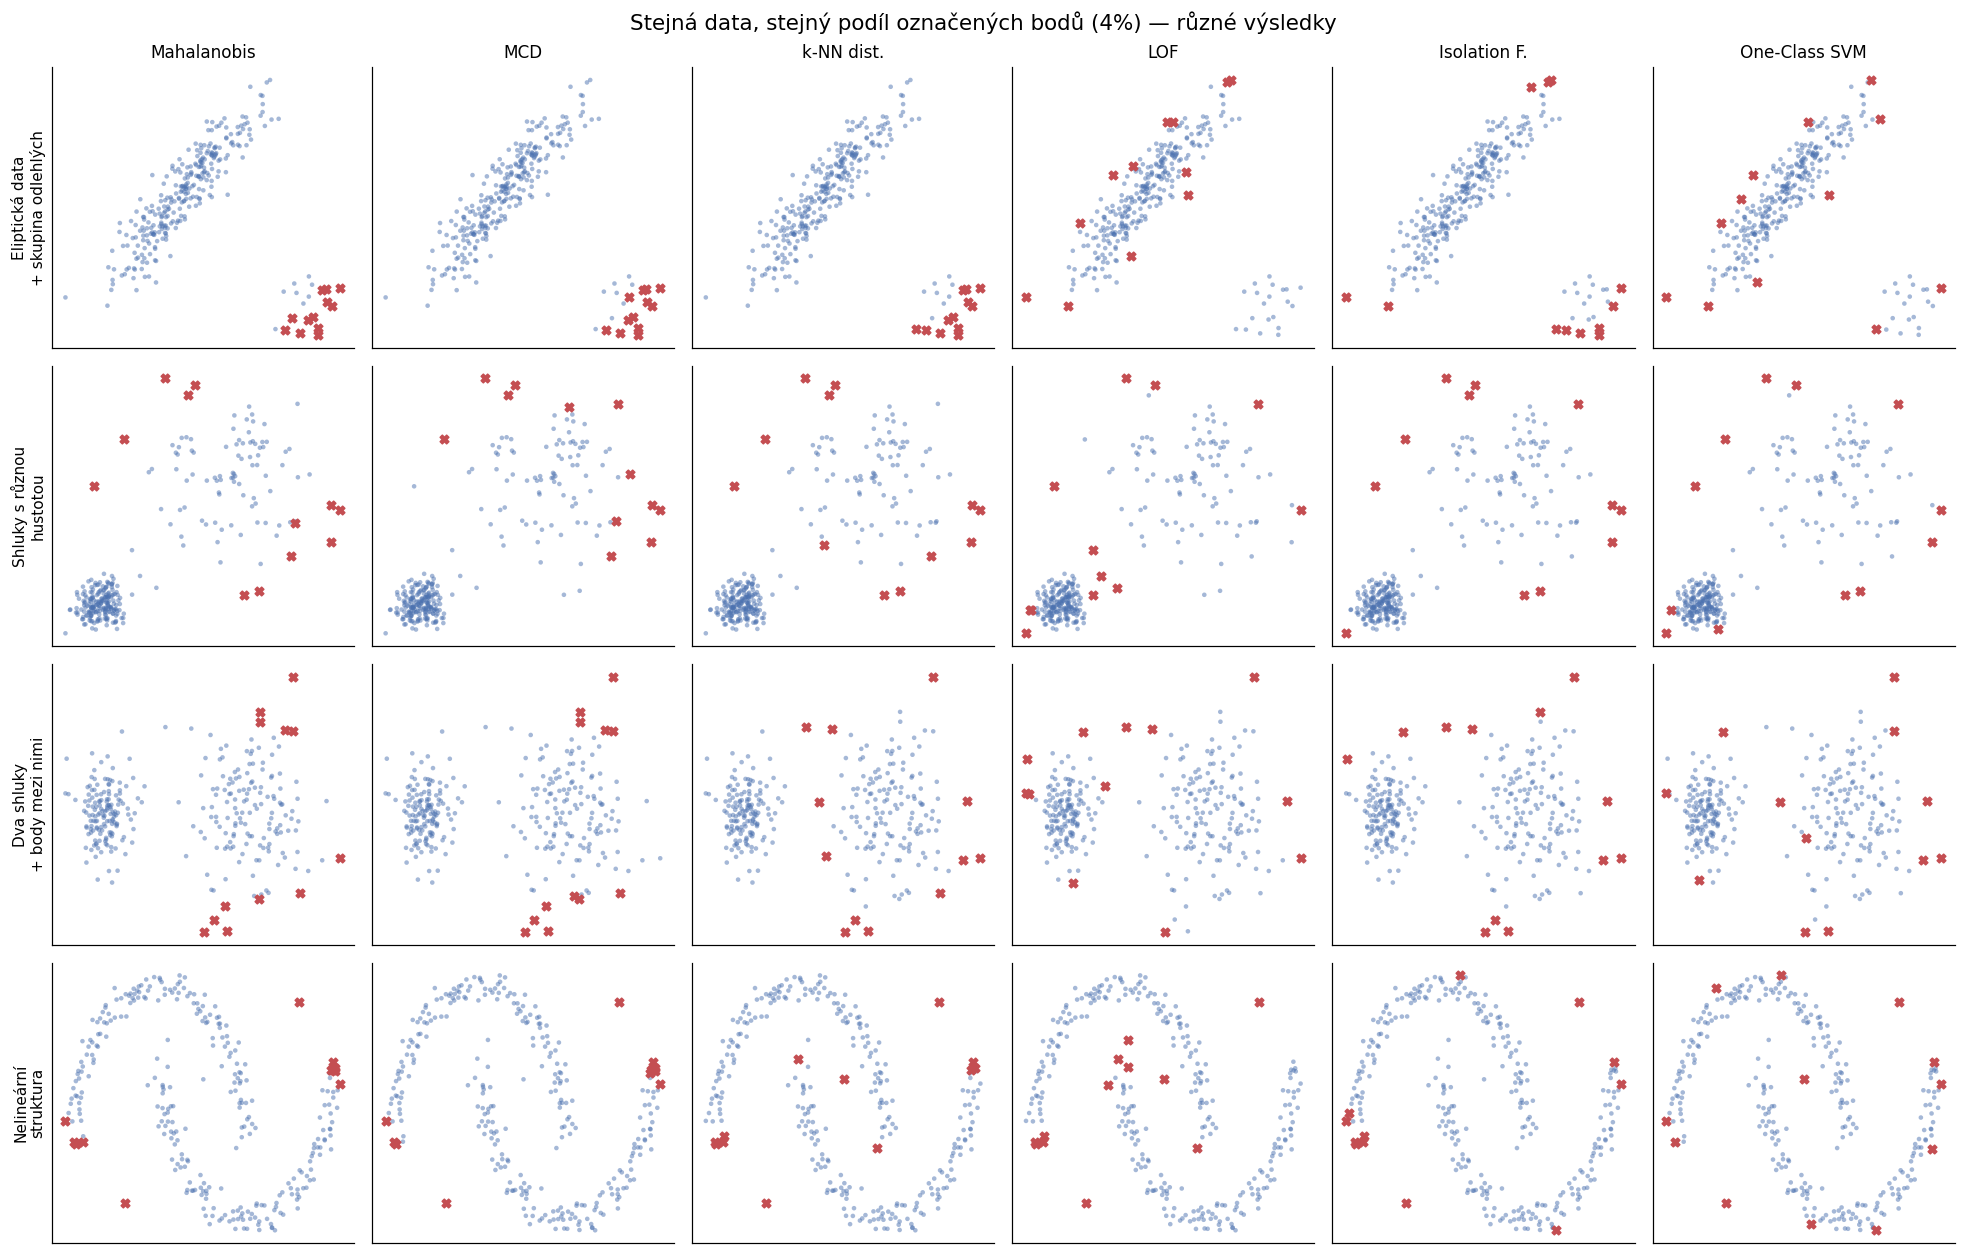

In [13]:
CONTAM = 0.04   # stejny podil "odlehlych" bodu pro vsechny metody i datasety -> ferove srovnani
nr, nc = len(DATASETS), len(METHODS)
fig, axes = plt.subplots(nr, nc, figsize=(3.0 * nc, 2.9 * nr))

# projedeme kazdou kombinaci (dataset x metoda) a vykreslime, ktere body byly oznaceny
for i, (dname, Xd) in enumerate(DATASETS.items()):
    for j, (mname, fn) in enumerate(METHODS.items()):
        ax = axes[i, j]
        f = flag_top(fn(Xd), CONTAM)
        ax.scatter(Xd[~f, 0], Xd[~f, 1], s=9, c=C_IN, alpha=.5, edgecolor='none')
        ax.scatter(Xd[f, 0], Xd[f, 1], s=32, c=C_OUT, marker='X')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)
        if i == 0:
            ax.set_title(mname, fontsize=11)
        if j == 0:
            ax.set_ylabel(dname, fontsize=10)

fig.suptitle('Stejná data, stejný podíl označených bodů ({:.0%}) — různé výsledky'.format(CONTAM),
             fontsize=14)
fig.tight_layout()
plt.show()

**Co si odnést z přehledové mřížky**

- Na eliptických datech se metody shodují — tam je volba téměř lhostejná.
- Při rozdílné hustotě shluků označí globální metody celý řidší shluk; LOF nikoli.
- U nelineárních struktur eliptické metody selhávají systematicky.
- Isolation Forest je kompromis: bez předpokladů, ale s tendencí preferovat okraje dat.

## 5.3 Výpočetní náročnost metod

Volba metody není jen otázka přesnosti — u větších datových souborů hraje roli i **rychlost**.
Podobné srovnání dělá ve své práci i Eliška Smazalová (kap. 5.5 diplomové práce, časová náročnost LOF).
Zde porovnáme škálování všech šesti metod se vzrůstajícím počtem pozorování $n$.

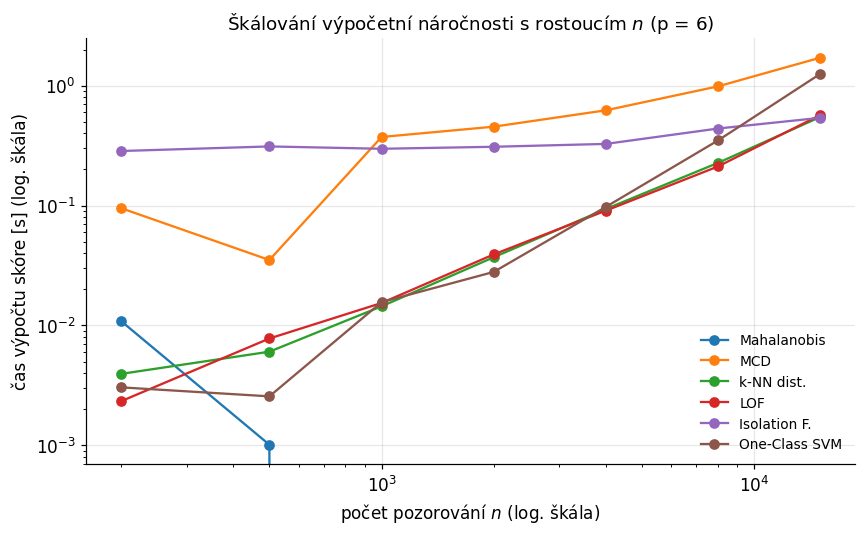

metoda,Isolation F.,LOF,MCD,Mahalanobis,One-Class SVM,k-NN dist.
n,,,,,,
200,0.285,0.002,0.095,0.011,0.003,0.004
500,0.311,0.008,0.035,0.001,0.003,0.006
1000,0.298,0.015,0.373,0.000,0.016,0.014
2000,0.309,0.039,0.455,0.000,0.028,0.037
4000,0.327,0.091,0.624,0.000,0.098,0.094
8000,0.439,0.212,0.988,0.000,0.350,0.227
15000,0.539,0.567,1.709,0.000,1.248,0.546


In [14]:
import time

# syntetická data (6 proměnných - stejný rozměr jako mamografická data) pro čistě výpočetní srovnání
n_values = [200, 500, 1000, 2000, 4000, 8000, 15000]
p_bench = 6

timing_rows = []
for n_ in n_values:
    Xb = RNG.normal(size=(n_, p_bench))
    for mname, fn in METHODS.items():
        t0 = time.time()
        fn(Xb)                       # spočítáme skóre - nás zajímá jen čas běhu
        timing_rows.append({'n': n_, 'metoda': mname, 'čas (s)': time.time() - t0})

timing = pd.DataFrame(timing_rows)

fig, ax = plt.subplots(figsize=(8, 5))
for mname in METHODS:
    sub = timing[timing['metoda'] == mname]
    ax.plot(sub['n'], sub['čas (s)'], 'o-', label=mname)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('počet pozorování $n$ (log. škála)')
ax.set_ylabel('čas výpočtu skóre [s] (log. škála)')
ax.set_title('Škálování výpočetní náročnosti s rostoucím $n$ (p = {})'.format(p_bench))
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

display(timing.pivot(index='n', columns='metoda', values='čas (s)').round(3))

**Poznámka k prezentaci:** Mahalanobis a k-NN/LOF škálují velmi dobře (lineárně až mírně superlineárně).
MCD a One-Class SVM rostou znatelně rychleji s $n$ — u desítek tisíc pozorování se to už projeví na
reálném čase čekání. Isolation Forest je téměř konstantní vůči $n$ (staví fixní počet stromů), což je
jeden z důvodů jeho popularity na velkých datech ve strojovém učení.

---
# 6. Prokletí dimenzionality

S rostoucím $p$ se vzdálenosti mezi body **koncentrují** — poměr nejvzdálenějšího a nejbližšího souseda jde k 1.
Pojem „blízkosti“ ztrácí rozlišovací schopnost a s ním i metody založené na vzdálenostech.

**Proč k tomu dochází (matematicky)**

Vzdálenost dvou náhodných bodů je součet $p$ nezávislých příspěvků, jednoho za každou dimenzi:

$$d(X,Y)^2 = \sum_{i=1}^p (X_i - Y_i)^2$$

Pro takový součet nezávislých, stejně rozdělených členů platí:

- **střední hodnota** roste lineárně s $p$: $\;E[d^2] = p \cdot \mu$
- **rozptyl** roste taky jen lineárně (díky nezávislosti členů): $\;\mathrm{Var}[d^2] = p \cdot \sigma^2$

Klíčový je jejich poměr — **relativní rozptyl** (variační koeficient) vzdálenosti:

$$\mathrm{CV}(d^2) = \frac{\sqrt{\mathrm{Var}[d^2]}}{E[d^2]} = \frac{\sqrt{\sigma^2/\mu^2}}{\sqrt{p}} \;\xrightarrow[p \to \infty]{}\; 0$$

Čili s rostoucím $p$ se vzdálenost mezi libovolnými dvěma náhodnými body čím dál přesněji rovná své střední hodnotě — náhodnost jednotlivých souřadnic se "vyprůměruje" stejně, jako se zákonem velkých čísel vyprůměruje šum u velkého počtu nezávislých měření.

**Formálně (Beyer et al., 1999):** pokud relativní rozptyl $\|X\|_p^p / p$ jde k nule s rostoucím $p$, pak pro nejvzdálenějšího ($D_{max}$) a nejbližšího ($D_{min}$) souseda libovolného dotazovacího bodu platí konvergence v pravděpodobnosti:

$$\frac{D_{max}}{D_{min}} \xrightarrow{P} 1$$

Když jsou si všechny vzdálenosti prakticky stejné, ztrácí smysl pojem "nejbližší soused" i "odlehlý bod" — a s ním selhávají k-NN, LOF i další metody založené na vzdálenosti.

*Poznámka: přesně to platí pro i.i.d. souřadnice. Reálná data s korelovanou nebo nízkodimenzionální (manifold) strukturou trpí méně, princip ale zůstává stejný.*

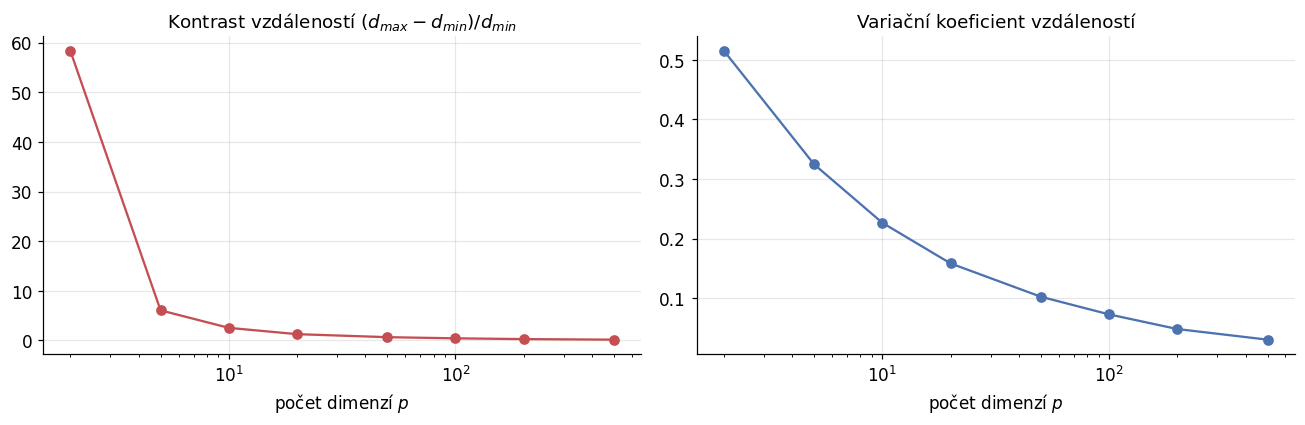

,p,kontrast,rel. rozptyl vzdáleností
0,2,58.317,0.515
1,5,6.071,0.325
2,10,2.545,0.227
3,20,1.274,0.159
4,50,0.669,0.103
5,100,0.435,0.073
6,200,0.280,0.049
7,500,0.168,0.031


In [15]:
# Simulujeme cist nahodna (standardni normalni) data v rostoucim poctu dimenzi
# a sledujeme, jak se meni pomer nejvzdalenejsiho a nejblizsiho souseda kazdeho bodu.
dims = [2, 5, 10, 20, 50, 100, 200, 500]
n_pts = 300
rows = []
for d in dims:
    Xd = RNG.normal(size=(n_pts, d))
    dist, _ = NearestNeighbors(n_neighbors=n_pts).fit(Xd).kneighbors(Xd)  # vzdalenosti ke vsem ostatnim bodum
    dmin, dmax = dist[:, 1], dist[:, -1]   # index 0 je vzdalenost bodu k sobe (=0), proto zaciname od 1
    rows.append({'p': d, 'kontrast': np.mean((dmax - dmin) / dmin),
                 'rel. rozptyl vzdáleností': dist[:, 1:].std() / dist[:, 1:].mean()})
tab = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# s rostoucim p se kontrast (rozdil mezi nejblizsim a nejvzdalenejsim sousedem) blizi nule
axes[0].plot(tab['p'], tab['kontrast'], 'o-', color=C_OUT)
axes[0].set_xscale('log')
axes[0].set_xlabel('počet dimenzí $p$')
axes[0].set_title(r'Kontrast vzdáleností $(d_{max}-d_{min})/d_{min}$')
axes[1].plot(tab['p'], tab['rel. rozptyl vzdáleností'], 'o-', color=C_IN)
axes[1].set_xscale('log')
axes[1].set_xlabel('počet dimenzí $p$')
axes[1].set_title('Variační koeficient vzdáleností')
fig.tight_layout()
plt.show()
display(tab.round(3))

In [16]:
# Druhy problem: odhad kovariancni matice vyzaduje n >> p (mnohem vic pozorovani nez promennych)
print('n   p   podmíněnost S      d_M^2 (max)')
for p_ in [2, 10, 30, 45, 49]:
    Xd = RNG.normal(size=(50, p_))            # jen 50 pozorovani, roste pocet promennych p_
    S = np.cov(Xd, rowvar=False)              # odhad kovariancni matice p_ x p_
    d2_ = EmpiricalCovariance().fit(Xd).mahalanobis(Xd)
    # podminenost (cond number) S roste prudce - matice se blizi singularni
    print('50 {:3d}   {:>12.1f}   {:>10.2f}'.format(p_, np.linalg.cond(S), d2_.max()))
print('\nPři p -> n je klasický Mahalanobis nepoužitelný (S je téměř singulární,')
print('všechna d_M^2 se blíží stejné hodnotě). Nutná regularizace nebo redukce dimenze.')

n   p   podmíněnost S      d_M^2 (max)
50   2            1.4        10.15
50  10            3.8        20.20
50  30           79.8        39.75
50  45          659.7   1690004837135179.50
50  49        50980.6        51.45

Při p -> n je klasický Mahalanobis nepoužitelný (S je téměř singulární,
všechna d_M^2 se blíží stejné hodnotě). Nutná regularizace nebo redukce dimenze.


---
# 7. Reálná data

Doposud jsme metody srovnávali na simulovaných datech, kde jsme znali „pravdu" o tom, co je
a co není odlehlé. V praxi to tak často nebývá. Ukážeme si obě situace:

- **7.1** — data **bez ground truth** (`wine`): metody lze srovnat jen mezi sebou (shoda/konsensus).
- **7.2** — data **s ground truth** (mamografie): můžeme spočítat, která metoda je skutečně blíž pravdě.

## 7.1 Bez ground truth: `wine` (178 vzorků, 13 proměnných)

Data načítáme pomocí `sklearn.datasets.load_wine`. Jde o dataset **Wine Recognition** z repozitáře **UCI Machine Learning Repository**, původně určený pro rozpoznávání odrůd vína podle chemických vlastností.

Odkazy: [UCI Wine Recognition dataset](https://archive.ics.uci.edu/dataset/109/wine) a [dokumentace `load_wine` ve scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html).

Nevíme, co je „skutečně" odlehlé — sledujeme jen, **nakolik se metody shodují** a jaká pozorování označují.

In [17]:
wine = load_wine()
Xw = StandardScaler().fit_transform(wine.data)   # standardizace - promenne maji velmi ruzna meritka
print('rozměr dat:', Xw.shape)

CONTAM_W = 0.05   # bez znalosti pravdy volime kontaminaci "od oka" (5 % je bezny vychozi odhad)
res_w = {name: flag_top(fn(Xw), CONTAM_W) for name, fn in METHODS.items()}
Fw = pd.DataFrame(res_w)   # sloupce = metody, radky = pozorovani, hodnoty = True/False (oznaceno jako odlehle)

print('\nPočet označených pozorování dle metody:')
display(Fw.sum().to_frame('n označených').T)

print('Označeno alespoň jednou metodou: {}   |   všemi metodami: {}'.format(
    int(Fw.any(axis=1).sum()), int(Fw.all(axis=1).sum())))

rozměr dat: (178, 13)

Počet označených pozorování dle metody:


,Mahalanobis,MCD,k-NN dist.,LOF,Isolation F.,One-Class SVM
n označených,9,9,9,9,9,9


Označeno alespoň jednou metodou: 19   |   všemi metodami: 3


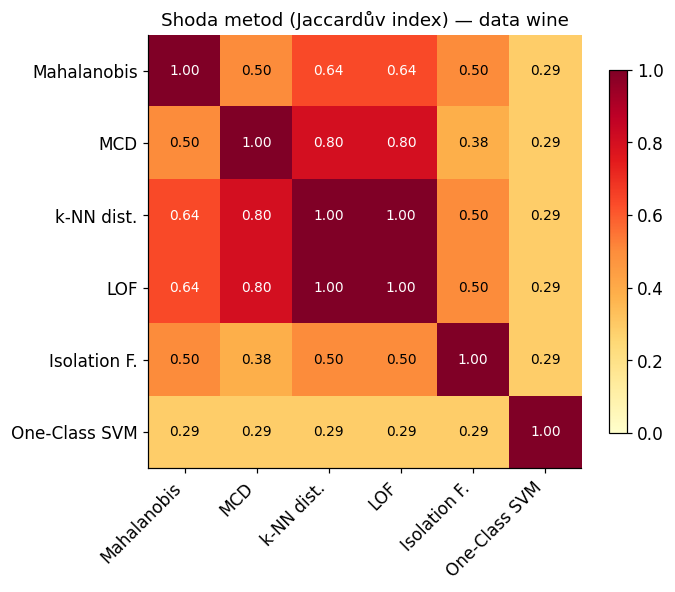

In [18]:
# Jaccardův index mezi dvojicemi metod = |shoda| / |sjednocení označených bodů|
# hodnota 1 = metody se shodují dokonale, 0 = žádný společný odlehlý bod
names_w = list(METHODS)
Jw = np.zeros((len(names_w), len(names_w)))
for i, a in enumerate(names_w):
    for j, b in enumerate(names_w):
        inter = (Fw[a] & Fw[b]).sum()
        union = (Fw[a] | Fw[b]).sum()
        Jw[i, j] = inter / union if union else 1.0

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(Jw, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(names_w)), names_w, rotation=45, ha='right')
ax.set_yticks(range(len(names_w)), names_w)
for i in range(len(names_w)):
    for j in range(len(names_w)):
        ax.text(j, i, '{:.2f}'.format(Jw[i, j]), ha='center', va='center',
                fontsize=9, color='k' if Jw[i, j] < 0.6 else 'w')
ax.grid(False)
ax.set_title('Shoda metod (Jaccardův index) — data wine')
fig.colorbar(im, shrink=.8)
fig.tight_layout()
plt.show()

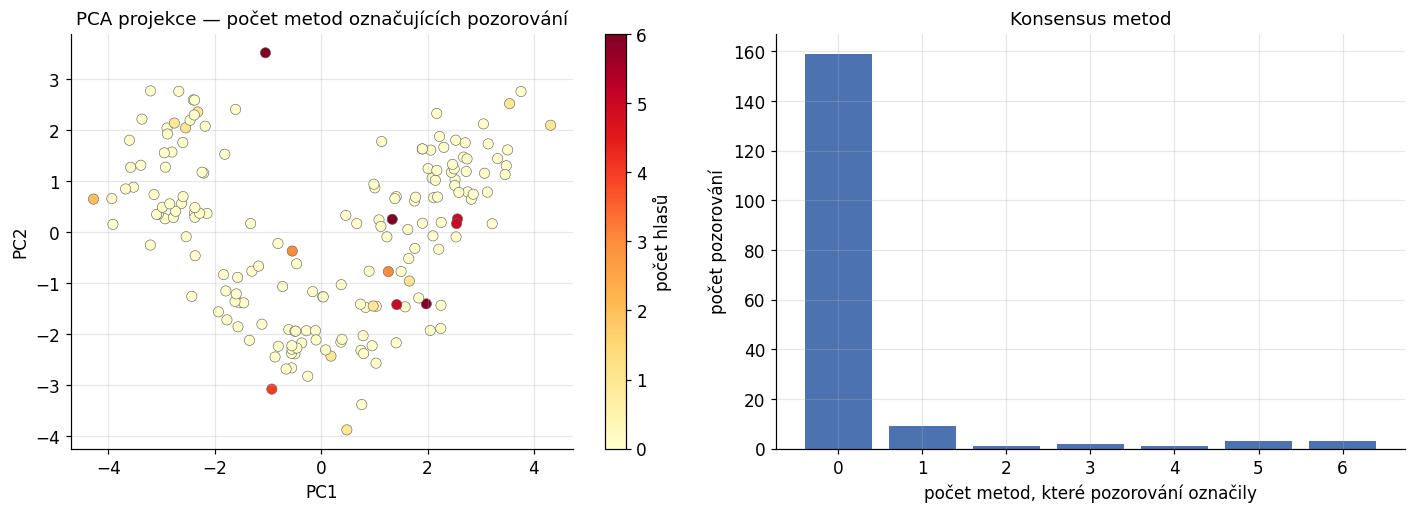

,index,počet hlasů,označily
0,121,6,"Mahalanobis, MCD, k-NN dist., LOF, Isolation F..."
1,69,6,"Mahalanobis, MCD, k-NN dist., LOF, Isolation F..."
2,158,6,"Mahalanobis, MCD, k-NN dist., LOF, Isolation F..."
3,73,5,"Mahalanobis, MCD, k-NN dist., LOF, One-Class SVM"
4,110,5,"Mahalanobis, MCD, k-NN dist., LOF, Isolation F."
5,95,5,"Mahalanobis, MCD, k-NN dist., LOF, Isolation F."
6,59,4,"Mahalanobis, k-NN dist., LOF, Isolation F."
7,96,3,"MCD, k-NN dist., LOF"
8,78,3,"MCD, k-NN dist., LOF"
9,146,2,"Isolation F., One-Class SVM"


In [19]:
# 2D PCA projekce pro vizualizaci 13-rozmerných dat + "hlasování" - kolik metod dany bod oznacilo
Zw = PCA(n_components=2, random_state=0).fit_transform(Xw)
votes_w = Fw.sum(axis=1).values   # pro kazdy bod: pocet metod (0 az 6), ktere ho oznacily jako odlehly

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sc = axes[0].scatter(Zw[:, 0], Zw[:, 1], c=votes_w, cmap='YlOrRd', s=45,
                     edgecolor='0.4', linewidth=.4)
axes[0].set_title('PCA projekce — počet metod označujících pozorování')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
fig.colorbar(sc, ax=axes[0], label='počet hlasů')

axes[1].bar(*np.unique(votes_w, return_counts=True), color=C_IN)
axes[1].set_xlabel('počet metod, které pozorování označily')
axes[1].set_ylabel('počet pozorování')
axes[1].set_title('Konsensus metod')
fig.tight_layout()
plt.show()

# top 10 bodu podle konsensu - nejrobustnejsi kandidati na skutecne odlehle
top_w = np.argsort(-votes_w)[:10]
display(pd.DataFrame({'index': top_w, 'počet hlasů': votes_w[top_w],
                      'označily': [', '.join(Fw.columns[Fw.iloc[i].values]) for i in top_w]}))

**Praktické doporučení (bez ground truth):** místo hledání „té správné" metody se vyplatí sledovat **konsensus**.
Pozorování označená většinou metod jsou robustní kandidáti; body označené jen jednou metodou vypovídají spíše
o vlastnostech metody než o datech. Toto je jediná dostupná strategie, pokud pravdu neznáme — což je většina
reálné praxe.

## 7.2 S ground truth (medicína): mamografie — detekce mikrokalcifikací

Dataset **Mammography** pochází z katalogu **ODDS (Outlier Detection DataSets)**, který jej přebírá z práce Woods et al. (1993) a uvádí jej v přehledu Rayana (2016). Obsahuje 11 183 segmentovaných
objektů z digitalizovaných mamogramů, 6 obrazových příznaků (plocha objektu, průměrná
sedotónová úroveň, gradient okraje, RMS šum, kontrast vůči okolí, tvarový moment).
Cílem je odlišit **mikrokalcifikace** (potenciální příznak zhoubného nádoru) od běžné tkáně.

Na rozdíl od `wine` zde **známe pravdu**: 260 objektů (2.32 %) je radiologicky
potvrzených jako mikrokalcifikace. To umožňuje metody nejen vzájemně porovnat, ale
i **kvantitativně vyhodnotit** proti skutečným štítkům (ROC-AUC, přesnost).

Katalogový záznam datasetu: http://odds.cs.stonybrook.edu/mammography-dataset/

> Datový soubor `mammography.csv` musí být ve stejné složce jako tento notebook.


In [20]:
mammo = pd.read_csv('mammography.csv')
y_true = mammo['odlehly'].values          # skutecne stitky: 1 = mikrokalcifikace, 0 = bezna tkan
Xm = mammo.drop(columns='odlehly').values
# priznaky jsou jiz standardizovane (viz zdroj), pro jistotu overime rozmer a pomer trid
print('rozměr dat:', Xm.shape)
print('mikrokalcifikace (odlehlé): {} z {}  ({:.2f} %)'.format(
    int(y_true.sum()), len(y_true), 100 * y_true.mean()))

CONTAM_M = y_true.mean()   # oznacime stejny podil, jaky je skutecny vyskyt (2.32 %) - ferove srovnani
scores_m = {name: fn(Xm) for name, fn in METHODS.items()}   # spojite skore kazde metody (pro pozdejsi ROC-AUC)
res_m = {name: flag_top(s, CONTAM_M) for name, s in scores_m.items()}   # binarni oznaceni top CONTAM_M podilu
F = pd.DataFrame(res_m)

print('\nPočet označených objektů dle metody (cíl: {}):'.format(int(y_true.sum())))
display(F.sum().to_frame('n označených').T)

rozměr dat: (11183, 6)
mikrokalcifikace (odlehlé): 260 z 11183  (2.32 %)

Počet označených objektů dle metody (cíl: 260):


,Mahalanobis,MCD,k-NN dist.,LOF,Isolation F.,One-Class SVM
n označených,260,260,260,260,260,260


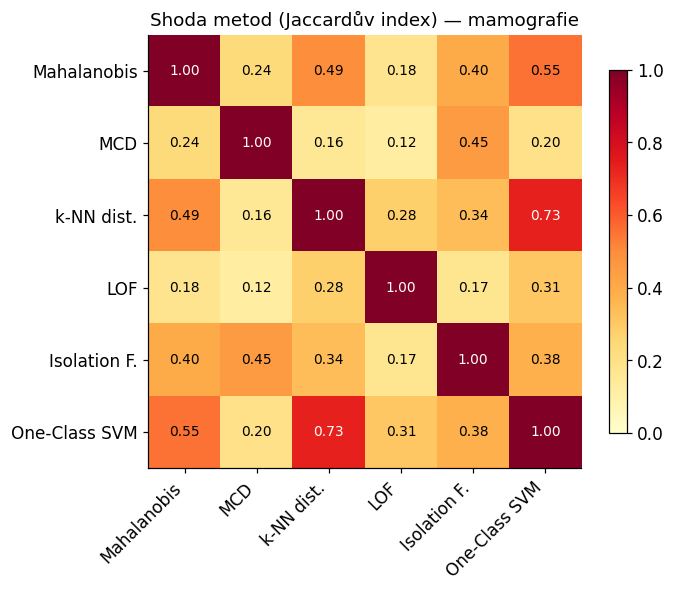

In [21]:
names = list(METHODS)
J = np.zeros((len(names), len(names)))
for i, a in enumerate(names):
    for j, b in enumerate(names):
        inter = (F[a] & F[b]).sum()
        union = (F[a] | F[b]).sum()
        J[i, j] = inter / union if union else 1.0

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(J, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(names)), names, rotation=45, ha='right')
ax.set_yticks(range(len(names)), names)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, '{:.2f}'.format(J[i, j]), ha='center', va='center',
                fontsize=9, color='k' if J[i, j] < 0.6 else 'w')
ax.grid(False)
ax.set_title('Shoda metod (Jaccardův index) — mamografie')
fig.colorbar(im, shrink=.8)
fig.tight_layout()
plt.show()

,metoda,ROC-AUC,přesnost@260
4,Isolation F.,0.864,0.258
0,Mahalanobis,0.860,0.269
2,k-NN dist.,0.851,0.250
1,MCD,0.837,0.069
3,LOF,0.720,0.192
5,One-Class SVM,0.690,0.269


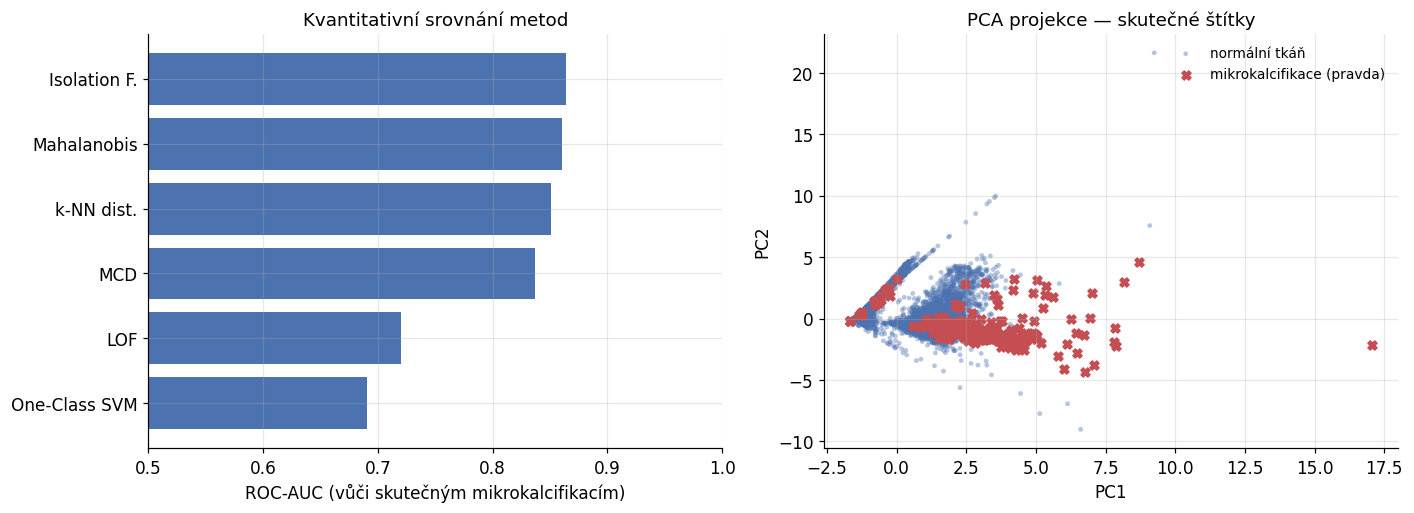

In [22]:
from sklearn.metrics import roc_auc_score

# na rozdil od wine ted mame ground truth (y_true) -> muzeme skore kazde metody kvantitativne overit
n_out = int(y_true.sum())
rows = []
for name, s in scores_m.items():
    auc = roc_auc_score(y_true, s)               # ROC-AUC: 0.5 = nahoda, 1.0 = dokonale rozliseni
    topk = np.argsort(-s)[:n_out]                # top n_out bodu podle skore
    prec = y_true[topk].mean()                   # jaky podil z nich je skutecne mikrokalcifikace
    rows.append({'metoda': name, 'ROC-AUC': auc, 'přesnost@{}'.format(n_out): prec})
eval_df = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False)
display(eval_df.round(3))

Z = PCA(n_components=2, random_state=0).fit_transform(Xm)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].barh(eval_df['metoda'], eval_df['ROC-AUC'], color=C_IN)
axes[0].set_xlim(0.5, 1.0)
axes[0].axvline(0.5, color='0.4', ls='--', lw=1)   # 0.5 = uroven nahodneho hadani
axes[0].set_xlabel('ROC-AUC (vůči skutečným mikrokalcifikacím)')
axes[0].set_title('Kvantitativní srovnání metod')
axes[0].invert_yaxis()

axes[1].scatter(Z[~y_true.astype(bool), 0], Z[~y_true.astype(bool), 1],
                s=10, c=C_IN, alpha=.4, edgecolor='none', label='normální tkáň')
axes[1].scatter(Z[y_true.astype(bool), 0], Z[y_true.astype(bool), 1],
                s=35, c=C_OUT, marker='X', label='mikrokalcifikace (pravda)')
axes[1].set_title('PCA projekce — skutečné štítky')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=9)
fig.tight_layout()
plt.show()

**Praktické doporučení:** na těchto datech mají **globální** metody (Mahalanobis, Isolation
Forest, k-NN vzdálenost) vyšší ROC-AUC než LOF a One-Class SVM — mikrokalcifikace se zde
odlišují spíše celkovou polohou v prostoru příznaků než lokální hustotou. To je pěkný protipól
k sekci 3 a 4, kde naopak LOF vítězilo nad Mahalanobisem: **žádná metoda není univerzálně
nejlepší, výsledek závisí na charakteru konkrétních dat** — přesně poselství abstraktu.

**Shrnutí sekce 7:** bez ground truth (wine) jsme mohli posoudit jen shodu metod mezi sebou.
S ground truth (mamografie) jsme mohli přímo změřit, která metoda je blíž pravdě — a ukázalo se,
že to není LOF, ačkoliv v sekcích 3–4 vycházelo jako „chytřejší" než klasický Mahalanobis.
Tento rozpor je záměrný: bez validace na skutečných datech nelze dopředu vědět, která metoda
na konkrétním problému zvítězí.

---
# 8. Shrnutí

In [23]:
# souhrnna tabulka pro rychlou orientaci (slidy shrnuti) - zadny vypocet, jen strukturovany prehled
summary = pd.DataFrame([
    ['Mahalanobis', 'globální, eliptická', 'interpretovatelná mez chi2, rychlý', 'není robustní (maskování), selže u shluků'],
    ['MCD-Mahalanobis', 'globální, eliptická', 'robustní, statisticky podložený', 'vyžaduje n >> p, stále eliptický pohled'],
    ['k-NN vzdálenost', 'globální hustota', 'jednoduchý, bez předpokladů tvaru', 'ignoruje rozdílnou hustotu shluků, citlivý na měřítko'],
    ['LOF', 'lokální hustota', 'zachytí lokální odlehlost', 'citlivý na k, skóre bez absolutní škály'],
    ['Isolation Forest', 'izolovatelnost', 'škáluje do vyšších dimenzí, rychlý', 'osové řezy, stochastický výsledek'],
    ['One-Class SVM', 'nosič rozdělení', 'flexibilní hranice', 'citlivý na nu a gamma, náročnější'],
], columns=['Metoda', 'Typ pohledu', 'Silné stránky', 'Omezení'])

display(summary)

,Metoda,Typ pohledu,Silné stránky,Omezení
0,Mahalanobis,"globální, eliptická","interpretovatelná mez chi2, rychlý","není robustní (maskování), selže u shluků"
1,MCD-Mahalanobis,"globální, eliptická","robustní, statisticky podložený","vyžaduje n >> p, stále eliptický pohled"
2,k-NN vzdálenost,globální hustota,"jednoduchý, bez předpokladů tvaru","ignoruje rozdílnou hustotu shluků, citlivý na ..."
3,LOF,lokální hustota,zachytí lokální odlehlost,"citlivý na k, skóre bez absolutní škály"
4,Isolation Forest,izolovatelnost,"škáluje do vyšších dimenzí, rychlý","osové řezy, stochastický výsledek"
5,One-Class SVM,nosič rozdělení,flexibilní hranice,"citlivý na nu a gamma, náročnější"


## Závěry

1. **Vícerozměrná odlehlost není součtem jednorozměrných.** Bod nenápadný ve všech marginálech může porušovat vztahy mezi proměnnými.
2. **Mahalanobisova vzdálenost** je stále dobrá první volba pro přibližně eliptická data — ale **jen v robustní variantě (MCD)**.
3. **LOF** odhalí lokálně odlehlá pozorování, která globální metody přehlédnou; cenou je volba $k$ a nesnadná interpretace skóre.
4. **S rostoucí dimenzí** slábne kontrast vzdáleností a odhad kovarianční matice; nutná redukce dimenze či regularizace.
5. **Neexistuje univerzálně nejlepší metoda.** Volba závisí na charakteru dat (elipticita, shluky, dimenze) a na cíli analýzy — jiné kritérium platí pro čištění dat před modelováním a jiné pro hledání zajímavých případů.
6. V praxi se osvědčuje **kombinace metod a sledování konsensu**, doplněná vždy o vizualizaci a věcnou interpretaci.
7. **Máte-li k dispozici ground truth** (byť jen na části dat), vždy validujte kvantitativně — intuice o tom, která metoda je „chytřejší", může být zavádějící (viz LOF vs. Mahalanobis na mamografických datech).

### Literatura

- Mahalanobis, P. C. (1936). *On the generalised distance in statistics.*
- Rousseeuw, P. J., Van Driessen, K. (1999). *A Fast Algorithm for the Minimum Covariance Determinant Estimator.* Technometrics.
- Breunig, M. et al. (2000). *LOF: Identifying Density-Based Local Outliers.* SIGMOD.
- Liu, F. T., Ting, K. M., Zhou, Z.-H. (2008). *Isolation Forest.* ICDM.
- Aggarwal, C. C. (2017). *Outlier Analysis.* 2nd ed., Springer.
- Schölkopf, B. et al. (2001). *Estimating the Support of a High-Dimensional Distribution.* Neural Computation.
- **UCI Machine Learning Repository.** *Wine Recognition Dataset.* https://archive.ics.uci.edu/dataset/109/wine
- **scikit-learn.** `load_wine` — Wine recognition dataset. https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html
- Woods, K. et al. (1993). *Comparative Evaluation of Pattern Recognition Techniques for Detection of Microcalcifications.*
- Rayana, S. (2016). *ODDS Library.* Stony Brook University. http://odds.cs.stonybrook.edu/
- **ODDS Mammography dataset.** http://odds.cs.stonybrook.edu/mammography-dataset/
